#**NAME :- Aryan Manoj Dubey**
#**UST24R0101008**
#**Topic:-Deep Embedded Clustering (Autoencoder+K-Means) for Image Dataset Organization**

  

In [1]:
import urllib.request
import os

url = "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/"

files = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz"
]

for file in files:
    urllib.request.urlretrieve(url + file, file)

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [2]:
os.listdir()

['.config',
 'train-images-idx3-ubyte.gz',
 't10k-images-idx3-ubyte.gz',
 'train-labels-idx1-ubyte.gz',
 't10k-labels-idx1-ubyte.gz',
 'sample_data']

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
import struct

#Load Fashion-MNIST manually

In [4]:
def load_images(file):
    with gzip.open(file, 'rb') as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols)

def load_labels(file):
    with gzip.open(file, 'rb') as f:
        magic, n = struct.unpack(">II", f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

x_train = load_images("train-images-idx3-ubyte.gz")
y_train = load_labels("train-labels-idx1-ubyte.gz")

x_test = load_images("t10k-images-idx3-ubyte.gz")
y_test = load_labels("t10k-labels-idx1-ubyte.gz")

print("Training:", x_train.shape)
print("Testing:", x_test.shape)

Training: (60000, 28, 28)
Testing: (10000, 28, 28)


In [5]:
print("Classes:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

Classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


#Display sample images

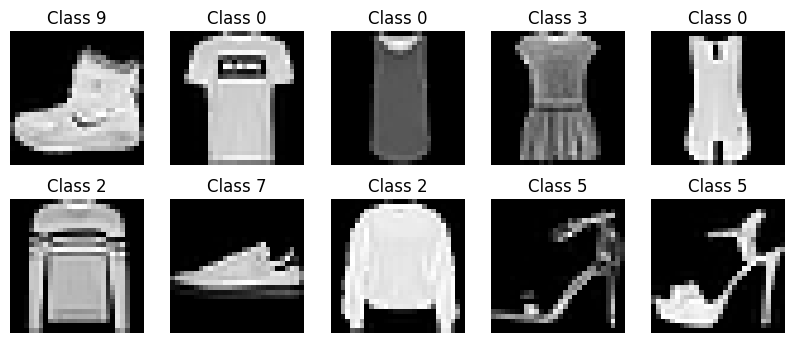

In [6]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Class " + str(y_train[i]))
    plt.axis("off")

plt.show()

#Normalize the images

In [7]:
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Minimum: 0.0
Maximum: 1.0


#Preparing images for Autoencoder

In [8]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (60000, 784)
Testing data: (10000, 784)


#ACTIVATION FUNCTION

In [9]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

In [28]:
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, latent_size) * np.sqrt(2 / hidden_size)
b2 = np.zeros((1, latent_size))

W3 = np.random.randn(latent_size, hidden_size) * np.sqrt(2 / latent_size)
b3 = np.zeros((1, hidden_size))

W4 = np.random.randn(hidden_size, input_size) * 0.01
b4 = np.zeros((1, input_size))

print("Autoencoder created!")

Autoencoder created!


#Forward propagation

In [18]:
def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    latent = relu(z2)

    z3 = latent @ W3 + b3
    a3 = relu(z3)

    z4 = a3 @ W4 + b4
    output = sigmoid(z4)

    return z1, a1, z2, latent, z3, a3, z4, output

In [19]:
sample = x_train[:10]

result = forward(sample)

print("Input shape:", sample.shape)
print("Latent shape:", result[3].shape)
print("Output shape:", result[7].shape)

Input shape: (10, 784)
Latent shape: (10, 32)
Output shape: (10, 784)


#Initial Reconstruction Loss

In [30]:
def loss_function(y, y_pred):
    return np.mean((y - y_pred) ** 2)

output = forward(x_train[:100])[7]
loss = loss_function(x_train[:100], output)

print("Initial loss:", loss)

Initial loss: 0.17249761071015937


#Backpropagation

In [27]:
def backward(X, cache, learning_rate=0.001):

    z1, a1, z2, latent, z3, a3, z4, output = cache

    m = X.shape[0]

    dz4 = (2 / m) * (output - X) * sigmoid_derivative(z4)

    dW4 = a3.T @ dz4
    db4 = np.sum(dz4, axis=0, keepdims=True)

    dz3 = (dz4 @ W4.T) * relu_derivative(z3)

    dW3 = latent.T @ dz3
    db3 = np.sum(dz3, axis=0, keepdims=True)

    dz2 = (dz3 @ W3.T) * relu_derivative(z2)

    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    dz1 = (dz2 @ W2.T) * relu_derivative(z1)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    W4[:] = W4 - learning_rate * dW4
    b4[:] = b4 - learning_rate * db4

    W3[:] = W3 - learning_rate * dW3
    b3[:] = b3 - learning_rate * db3

    W2[:] = W2 - learning_rate * dW2
    b2[:] = b2 - learning_rate * db2

    W1[:] = W1 - learning_rate * dW1
    b1[:] = b1 - learning_rate * db1

#Test One Training Step

In [32]:
X_batch = x_train[:256]

cache = forward(X_batch)

before_loss = loss_function(X_batch, cache[7])

backward(X_batch, cache, learning_rate=0.001)

output = forward(X_batch)[7]

after_loss = loss_function(X_batch, output)

print("Loss before:", before_loss)
print("Loss after:", after_loss)

Loss before: 0.16931195673451035
Loss after: 0.16892383802215738


#Training Function

In [33]:
def train(X, epochs=5, batch_size=256, learning_rate=0.001):

    n = len(X)

    for epoch in range(epochs):

        order = np.random.permutation(n)
        total_loss = 0

        for start in range(0, n, batch_size):

            batch = X[order[start:start + batch_size]]

            cache = forward(batch)

            total_loss += loss_function(batch, cache[7])

            backward(batch, cache, learning_rate)

        avg_loss = total_loss / np.ceil(n / batch_size)

        print("Epoch", epoch + 1, "Loss:", avg_loss)

#Train the Autoencoder

In [36]:
train(
    x_train,
    epochs=5,
    batch_size=256,
    learning_rate=0.001
)

Epoch 1 Loss: 0.03231563948511375
Epoch 2 Loss: 0.029557489471151614
Epoch 3 Loss: 0.02801606554600626
Epoch 4 Loss: 0.026990569693467886
Epoch 5 Loss: 0.026221645961523737


# Checking Reconstruction

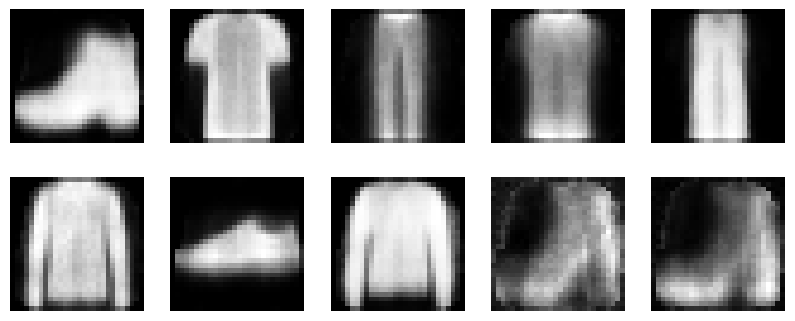

In [37]:
sample = x_train[:10]

reconstructed = forward(sample)[7]

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

In [38]:
latent_features = forward(x_train)[3]

print("Latent feature shape:", latent_features.shape)

Latent feature shape: (60000, 32)


#K-Means from Scratch

In [39]:
class KMeansScratch:

    def __init__(self, k=10, max_iter=15):
        self.k = k
        self.max_iter = max_iter

    def predict(self, X):

        labels = []

        for start in range(0, len(X), 1000):

            batch = X[start:start + 1000]

            distances = np.sum(
                (batch[:, None, :] - self.centroids[None, :, :]) ** 2,
                axis=2
            )

            labels.extend(np.argmin(distances, axis=1))

        return np.array(labels)

    def fit(self, X):

        np.random.seed(42)

        indices = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[indices].copy()

        for i in range(self.max_iter):

            labels = self.predict(X)

            new_centroids = []

            for j in range(self.k):

                points = X[labels == j]

                if len(points) > 0:
                    new_centroids.append(points.mean(axis=0))
                else:
                    new_centroids.append(self.centroids[j])

            new_centroids = np.array(new_centroids)

            if np.allclose(self.centroids, new_centroids):
                break

            self.centroids = new_centroids

        self.labels_ = self.predict(X)

        return self

In [40]:
kmeans = KMeansScratch(k=10, max_iter=15)

kmeans.fit(latent_features)

print("K-Means training completed!")

K-Means training completed!


In [41]:
cluster_labels = kmeans.labels_

print("Cluster labels shape:", cluster_labels.shape)
print("Number of clusters:", len(np.unique(cluster_labels)))

for i in range(10):
    print("Cluster", i, ":", np.sum(cluster_labels == i), "images")

Cluster labels shape: (60000,)
Number of clusters: 10
Cluster 0 : 8219 images
Cluster 1 : 5303 images
Cluster 2 : 8407 images
Cluster 3 : 4292 images
Cluster 4 : 2604 images
Cluster 5 : 5130 images
Cluster 6 : 7348 images
Cluster 7 : 3973 images
Cluster 8 : 6327 images
Cluster 9 : 8397 images


#Calculate Inertia Manually

In [42]:
inertia = 0

for i in range(10):
    points = latent_features[cluster_labels == i]
    center = kmeans.centroids[i]

    inertia += np.sum((points - center) ** 2)

print("Inertia:", inertia)

Inertia: 3373927.111667335


#Silhouette Score

In [43]:
def silhouette_score_manual(X, labels, sample_size=1000):

    np.random.seed(42)

    indices = np.random.choice(len(X), sample_size, replace=False)

    X_sample = X[indices]
    labels_sample = labels[indices]

    scores = []

    for i in range(sample_size):

        current = X_sample[i]
        current_label = labels_sample[i]

        same_cluster = X_sample[labels_sample == current_label]

        if len(same_cluster) > 1:
            distances = np.sqrt(np.sum((same_cluster - current) ** 2, axis=1))
            a = np.mean(distances[distances > 0])
        else:
            a = 0

        b = np.inf

        for cluster in np.unique(labels_sample):

            if cluster == current_label:
                continue

            other_cluster = X_sample[labels_sample == cluster]

            distances = np.sqrt(
                np.sum((other_cluster - current) ** 2, axis=1)
            )

            b = min(b, np.mean(distances))

        score = (b - a) / max(a, b)
        scores.append(score)

    return np.mean(scores)


silhouette = silhouette_score_manual(
    latent_features,
    cluster_labels
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.28575461915809647


#Adjusted Rand Index (ARI)

In [44]:
def ari_score_manual(y_true, y_pred):

    n = len(y_true)

    table = np.zeros((10, 10), dtype=int)

    for a, b in zip(y_true, y_pred):
        table[a, b] += 1

    def comb2(x):
        return x * (x - 1) / 2

    sum_ij = np.sum(comb2(table))

    row_sums = np.sum(table, axis=1)
    col_sums = np.sum(table, axis=0)

    sum_rows = np.sum(comb2(row_sums))
    sum_cols = np.sum(comb2(col_sums))

    total = comb2(n)

    expected = (sum_rows * sum_cols) / total

    max_index = 0.5 * (sum_rows + sum_cols)

    return (sum_ij - expected) / (max_index - expected)


ari = ari_score_manual(y_train, cluster_labels)

print("ARI:", ari)

ARI: 0.34349361384403987


#Cluster vs Class Distribution

In [45]:
table = np.zeros((10, 10), dtype=int)

for cluster in range(10):
    table[cluster] = np.bincount(
        y_train[cluster_labels == cluster],
        minlength=10
    )

print(pd.DataFrame(
    table,
    index=[f"Cluster {i}" for i in range(10)],
    columns=[f"Class {i}" for i in range(10)]
))

           Class 0  Class 1  Class 2  Class 3  Class 4  Class 5  Class 6  \
Cluster 0     1722      317     1540     1083      895      101     1911   
Cluster 1        0        0        0        0        0      298        0   
Cluster 2        6        0        8        0        2     1340       11   
Cluster 3      477      306       66     2269      804        1      335   
Cluster 4       26        0       22        9       40       16       13   
Cluster 5      170       44     1857       31      832        1      992   
Cluster 6       60     5149        3     2043       61        1       23   
Cluster 7     2881       76       27      223       39        2      708   
Cluster 8       64       26     1829       93     3106        0     1174   
Cluster 9      594       82      648      249      221     4240      833   

           Class 7  Class 8  Class 9  
Cluster 0        2      569       79  
Cluster 1      217       32     4756  
Cluster 2     4990     1176      874  
Cluster

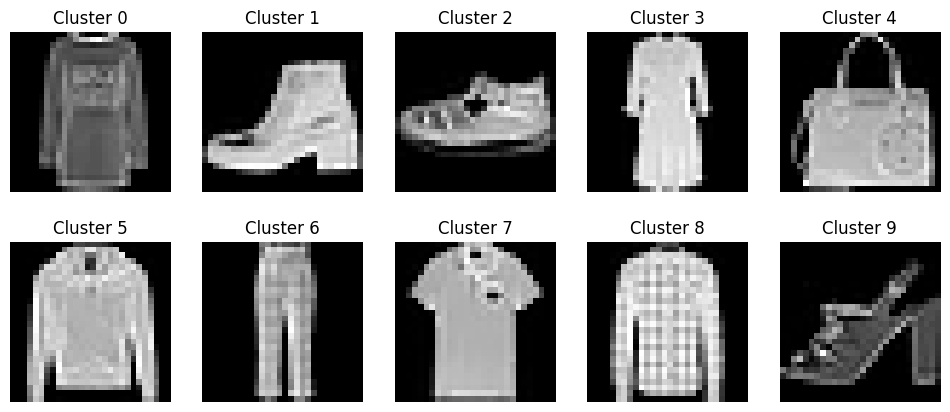

In [46]:
representatives = []

for i in range(10):

    indices = np.where(cluster_labels == i)[0]

    points = latent_features[indices]

    distances = np.sum(
        (points - kmeans.centroids[i]) ** 2,
        axis=1
    )

    representatives.append(
        indices[np.argmin(distances)]
    )


plt.figure(figsize=(12, 5))

for i, idx in enumerate(representatives):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_train[idx].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Cluster " + str(i))
    plt.axis("off")

plt.show()

#2D Visualization of Latent Clusters

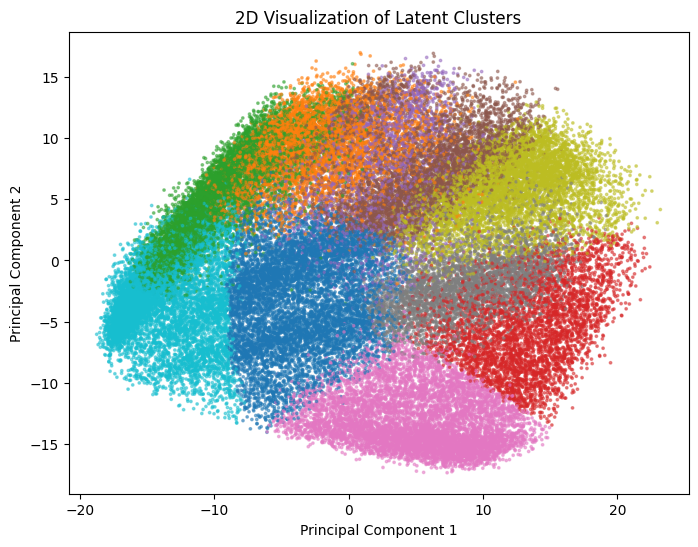

In [47]:
X_centered = latent_features - latent_features.mean(axis=0)

cov = (X_centered.T @ X_centered) / (len(X_centered) - 1)

values, vectors = np.linalg.eigh(cov)

order = np.argsort(values)[::-1]

components = vectors[:, order[:2]]

latent_2d = X_centered @ components

plt.figure(figsize=(8, 6))

plt.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=3,
    alpha=0.5
)

plt.title("2D Visualization of Latent Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

#Autoencoder Training Loss

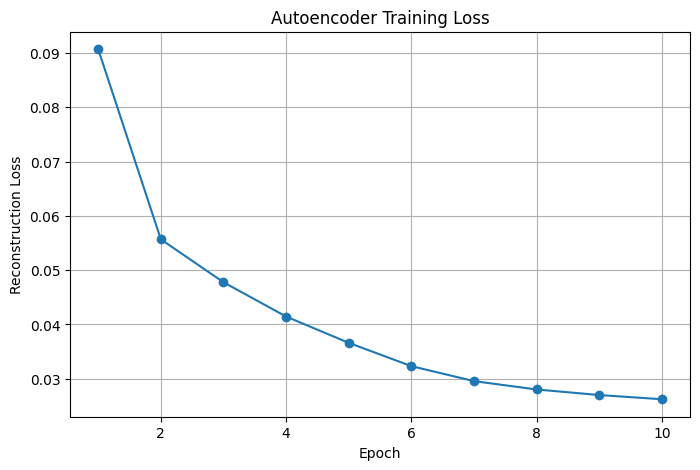

In [48]:
loss_history = [
    0.0906851120,
    0.0556697621,
    0.0477696149,
    0.0414501296,
    0.0366074904,
    0.0323156395,
    0.0295574895,
    0.0280160655,
    0.0269905697,
    0.0262216450
]

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.grid()

plt.show()

#Final Results Summary

In [49]:
print("FINAL RESULTS")
print("---------------------------")

print("Training images:", len(x_train))
print("Latent features:", latent_features.shape[1])
print("Number of clusters:", kmeans.k)

print("Inertia:", inertia)
print("Silhouette Score:", silhouette)
print("ARI:", ari)

print("---------------------------")
print("Autoencoder and K-Means completed successfully!")

FINAL RESULTS
---------------------------
Training images: 60000
Latent features: 32
Number of clusters: 10
Inertia: 3373927.111667335
Silhouette Score: 0.28575461915809647
ARI: 0.34349361384403987
---------------------------
Autoencoder and K-Means completed successfully!


#OOP addition

In [50]:
class AutoencoderScratch:

    def fit(self, X, epochs=5, batch_size=256, learning_rate=0.001):
        train(X, epochs, batch_size, learning_rate)

    def predict(self, X):
        return forward(X)[7]

    def encode(self, X):
        return forward(X)[3]

In [51]:
autoencoder = AutoencoderScratch()

print("Reconstruction:", autoencoder.predict(x_train[:10]).shape)
print("Latent:", autoencoder.encode(x_train[:10]).shape)

Reconstruction: (10, 784)
Latent: (10, 32)


## Conclusion

The project successfully clustered **60,000 Fashion-MNIST images** into **10 clusters** using a **32-dimensional latent space**. The final reconstruction loss was **0.02622**, with an **Inertia of 3,373,927.11**, **Silhouette Score of 0.28575**, and **ARI of 0.34349**. These results show that the autoencoder learned useful features and grouped visually similar images into meaningful clusters.